# DINOv3 (timm) + Attention Head + Focal Loss — Kaggle T4×2

Przeróbka `EfficientNetV2_FocalLoss.ipynb` w oparciu o uwagi kolegi (F1 ~0.82 z walidacją).

**Środowisko: Kaggle Notebook, akcelerator: GPU T4×2.** Wykorzystujemy obydwa T4 przez `nn.DataParallel` — w notebooku to najprostsza droga (DDP wymaga skryptu `.py` lub `mp.spawn` co jest upierdliwe w Jupyterze).

**Wagi DINOv3 z timm — publiczne, bez gated repo.**

| zmiana | dlaczego |
|---|---|
| **Backbone:** EfficientNetV2-S → **DINOv3 ViT-L/16** (timm, ~300M) | foundation model, silniejsze cechy |
| **Głowa:** prosty Linear → **Attention pooling + MLP** | lepsze niż samo CLS-token |
| **Trening 2-fazowy:** zamrożony backbone → ostatnie 20/24 warstwy | dokładnie to co kolega zrobił |
| **Focal Loss bez alpha** | kolega: "weights seemed to lower F1" |
| **Crop bez paddingu** | kolega: "no padding" |
| Augmentacje per kamera + flip ze swapem L↔R | jak w oryginale |
| **Mixed precision fp16** (T4 nie ma bf16) | bez tego ViT-L się nie zmieści |
| **DataParallel na 2× T4** | ~1.7× szybciej niż jedna T4 |

### Konfiguracja Kaggle
1. **Settings (panel po prawej):**
   - Accelerator: **GPU T4×2**
   - Internet: **ON** (timm pobiera wagi z HF Hub)
2. **Dataset:** wgraj `multi-view-pig-posture-recognition` przez „+ Add Input” (Datasets), żeby był w `/kaggle/input/...`. Albo jeśli to konkurs Kaggle → „+ Add Input” → Competitions.
3. Save Version → wybierz „Save & Run All”, żeby trening leciał w tle (do 12h).

**Limit Kaggle:** 30h GPU/tydzień, max 12h na sesję. Reset poniedziałki 00:00 UTC.

In [1]:
# ── Instalacja zależności (Colab) ─────────────────────────────────────────────
# timm >= 1.0.9 ma DINOv3 ViT (sprawdzane: timm 1.0.11+ działa stabilnie)
!pip install -q --upgrade timm
import timm; print(f'timm version: {timm.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.1 MB/s eta 0:00:0000:010:01
timm version: 1.0.27


In [5]:
!ls /kaggle/input

competitions


In [6]:
import ast, copy, re, time
from collections import Counter

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

import timm

torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if DEVICE.type == 'cuda' else 0
USE_DATA_PARALLEL = NUM_GPUS >= 2

print(f'Device: {DEVICE}')
print(f'Liczba GPU: {NUM_GPUS}')
if NUM_GPUS > 0:
    for i in range(NUM_GPUS):
        print(f'  [{i}] {torch.cuda.get_device_name(i)}')
    bf16_ok = torch.cuda.is_bf16_supported()
    # T4 NIE wspiera bf16 — wymusza fp16
    AMP_DTYPE = torch.bfloat16 if bf16_ok else torch.float16
    print(f'bfloat16 supported: {bf16_ok}  →  AMP dtype: {AMP_DTYPE}')
    print(f'DataParallel: {USE_DATA_PARALLEL}')
else:
    AMP_DTYPE = torch.float32
    print('⚠ Brak GPU — trening będzie ekstremalnie wolny!')

Device: cuda
Liczba GPU: 2
  [0] Tesla T4
  [1] Tesla T4
bfloat16 supported: True  →  AMP dtype: torch.bfloat16
DataParallel: True


In [21]:
# ── Konfiguracja ──────────────────────────────────────────────────────────────
CLASS_NAMES = {
    0: 'Lateral_lying_left',
    1: 'Lateral_lying_right',
    2: 'Sitting',
    3: 'Standing',
    4: 'Sternal_lying',
}
NUM_CLASSES = len(CLASS_NAMES)

BASE_DIR = Path("/kaggle/input/competitions/multi-view-pig-posture-recognition/multiview_pig_posture_recognition")
TRAIN2_IMGS = BASE_DIR / 'train2_images'
TEST_IMGS   = BASE_DIR / 'test_images'

# ── Backbone DINOv3 (timm — dystylowane z ViT-7B na LVD-1689M) ────────────────
DINOV3_VARIANTS = {
    'vitb16':     'vit_base_patch16_dinov3.lvd1689m',       # ~86M,  12 warstw
    'vitl16':     'vit_large_patch16_dinov3.lvd1689m',      # ~300M, 24 warstwy
    'vith16plus': 'vit_huge_plus_patch16_dinov3.lvd1689m',  # ~840M, 32 warstwy
}
DINOV3_VARIANT = 'vitl16'
DINOV3_REPO    = DINOV3_VARIANTS[DINOV3_VARIANT]

IMG_SIZE = 224

# BATCH_SIZE = łączny dla wszystkich GPU (DataParallel rozdzieli na pół).
# Z 2× T4 (16GB) + ViT-L + fp16 mieści się 32 (16/GPU). Na 1 GPU daj 16.
BATCH_SIZE = 32 if USE_DATA_PARALLEL else 16

# ── Focal Loss ────────────────────────────────────────────────────────────────
# Kolega: "used Focal loss with no weights. weights seemed to lower F1"
FOCAL_GAMMA = 1.5
USE_ALPHA   = False

# ── 2-fazowy trening (workflow kolegi) ────────────────────────────────────────
EPOCHS_P1 = 6
LR_P1     = 1e-3

EPOCHS_P2 = 8
LR_P2     = 5e-5
UNFREEZE_LAST_N_LAYERS = 20

# ── Wyjścia (Kaggle zapisuje do /kaggle/working/, który jest w outputach) ─────
OUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
SAVE_PHASE1     = str(OUT_DIR / f'dinov3_{DINOV3_VARIANT}_phase1.pt')
SAVE_PHASE2     = str(OUT_DIR / f'dinov3_{DINOV3_VARIANT}_phase2.pt')
SUBMISSION_PATH = str(OUT_DIR / f'submission_dinov3_{DINOV3_VARIANT}.csv')

print(f'DINOv3:        {DINOV3_REPO}')
print(f'Image size:    {IMG_SIZE}×{IMG_SIZE}')
print(f'Batch size:    {BATCH_SIZE}  ({BATCH_SIZE // max(NUM_GPUS,1)}/GPU)')
print(f'Focal γ={FOCAL_GAMMA}, alpha={USE_ALPHA}')
print(f'Phase 1: {EPOCHS_P1} epok @ lr={LR_P1} (backbone frozen)')
print(f'Phase 2: {EPOCHS_P2} epok @ lr={LR_P2} (last {UNFREEZE_LAST_N_LAYERS} layers unfrozen)')
print(f'Output dir:    {OUT_DIR}')

DINOv3:        vit_large_patch16_dinov3.lvd1689m
Image size:    224×224
Batch size:    32  (16/GPU)
Focal γ=1.5, alpha=False
Phase 1: 6 epok @ lr=0.001 (backbone frozen)
Phase 2: 8 epok @ lr=5e-05 (last 20 layers unfrozen)
Output dir:    /kaggle/working


## Focal Loss (bez wag — wg uwag kolegi)

In [9]:
class FocalLoss(nn.Module):
    """
    Focal Loss dla klasyfikacji wieloklasowej.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma:  focusing parameter (0 = identyczny z CE, zalecane: 1–2)
        alpha:  tensor wag klas (opcjonalny); ten sam format co
                weight w nn.CrossEntropyLoss. UWAGA: kolega zalecił alpha=None.
    """
    def __init__(self, gamma: float = 1.5, alpha: torch.Tensor = None):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer('alpha', alpha.float())
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        focal = (1.0 - pt) ** self.gamma * ce
        return focal.mean()

    def extra_repr(self):
        return f'gamma={self.gamma}, alpha={"tak" if self.alpha is not None else "brak"}'

# Test poprawności
with torch.no_grad():
    _l = torch.randn(8, NUM_CLASSES); _t = torch.randint(0, NUM_CLASSES, (8,))
    _ce  = F.cross_entropy(_l, _t).item()
    _fl0 = FocalLoss(gamma=0.0)(_l, _t).item()
    assert abs(_ce - _fl0) < 1e-4, 'FocalLoss(γ=0) ≠ CE'
    print(f'CE={_ce:.4f}  FL(γ=0)={_fl0:.4f}  FL(γ={FOCAL_GAMMA})={FocalLoss(gamma=FOCAL_GAMMA)(_l,_t).item():.4f}  ✓')

CE=1.6322  FL(γ=0)=1.6322  FL(γ=1.5)=1.2140  ✓


## Wczytanie danych

In [22]:
def parse_camera_meta(image_id):
    m = re.match(r'(pen\d+)_(orb|tur)_(cam\d+)_', str(image_id))
    return (m.group(1), m.group(2), m.group(3)) if m else ('unknown', 'unknown', 'unknown')

def add_camera_cols(df):
    df['pen']      = df['image_id'].apply(lambda x: parse_camera_meta(x)[0])
    df['cam_type'] = df['image_id'].apply(lambda x: parse_camera_meta(x)[1])
    df['cam_num']  = df['image_id'].apply(lambda x: parse_camera_meta(x)[2])
    df['camera']   = df['pen'] + '_' + df['cam_type'] + '_' + df['cam_num']
    return df

train2 = pd.read_csv(BASE_DIR / 'train2.csv')
train2['source']      = 'train2'
train2['bbox_parsed'] = train2['bbox'].apply(ast.literal_eval)
train2['class_name']  = train2['class_id'].map(CLASS_NAMES)
train2 = add_camera_cols(train2)

test = pd.read_csv(BASE_DIR / 'test.csv')
test['source']      = 'test'
test['bbox_parsed'] = test['bbox'].apply(ast.literal_eval)
test = add_camera_cols(test)

print(f'Train2: {len(train2):,} instancji  |  {train2["image_id"].nunique():,} zdjęć')
print(f'Test:   {len(test):,} instancji   |  {test["image_id"].nunique():,} zdjęć')
print('\nRozkład klas (train2):')
for cname, cnt in train2['class_name'].value_counts().items():
    print(f'  {cname:25s}: {cnt:,}')

Train2: 23,450 instancji  |  3,150 zdjęć
Test:   11,708 instancji   |  1,350 zdjęć

Rozkład klas (train2):
  Standing                 : 9,928
  Sternal_lying            : 6,309
  Lateral_lying_right      : 3,435
  Lateral_lying_left       : 3,083
  Sitting                  : 695


In [11]:
# ── Narzędzia obrazu — CROP BEZ PADDINGU (uwaga kolegi) ──────────────────────
def load_image(image_id, source):
    folder = {'train2': TRAIN2_IMGS, 'test': TEST_IMGS}[source]
    return Image.open(folder / image_id).convert('RGB')

def crop_bbox(image, bbox):
    """Crop bezpośrednio z bboxa — bez paddingu, bez make_square.
    Kolega: 'i just cropped the bounded regions resized to similar resolution. no padding.'
    """
    img_w, img_h = image.size
    x, y, w, h   = map(float, bbox)
    x1 = max(0, int(round(x)))
    y1 = max(0, int(round(y)))
    x2 = min(img_w, int(round(x + w)))
    y2 = min(img_h, int(round(y + h)))
    return image.crop((x1, y1, max(x2, x1+1), max(y2, y1+1)))

In [23]:
# ── Augmentacje per kamera (jak w oryginale — kolega kazał zostawić) ─────────
# UWAGA: horizontal flip wymaga zamiany etykiet 0 (left lying) ↔ 1 (right lying).
# Klasy 2–4 są symetryczne, etykieta bez zmian.
# Vertical flip: NIE używamy (uwaga kolegi).

FLIP_LABEL_MAP = {0: 1, 1: 0, 2: 2, 3: 3, 4: 4}

def aug_pen2_tur_cam1(img):
    img = TF.hflip(img)
    img = TF.adjust_saturation(img, saturation_factor=0.8)
    return TF.adjust_brightness(img, brightness_factor=0.95)

def aug_pen1_tur_cam2(img):
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=1.35)
    return TF.adjust_saturation(img, saturation_factor=0.9)

def aug_pen2_orb_cam1(img):
    img = TF.hflip(img)
    img = TF.adjust_brightness(img, brightness_factor=0.6)
    img = TF.adjust_contrast(img, contrast_factor=1.5)
    arr = np.array(img).astype(float)
    arr[:,:,0] = (arr[:,:,0] * 0.85).clip(0, 255)
    arr[:,:,1] = (arr[:,:,1] * 1.10).clip(0, 255)
    arr[:,:,2] = (arr[:,:,2] * 0.80).clip(0, 255)
    shifted = Image.fromarray(arr.clip(0,255).astype(np.uint8))
    grey    = np.array(TF.to_grayscale(shifted, num_output_channels=3)).astype(float)
    return Image.fromarray((0.65*arr + 0.35*grey).clip(0,255).astype(np.uint8))

def aug_pen2_tur_cam2(img):
    img = TF.adjust_brightness(img, brightness_factor=1.3)
    return TF.adjust_saturation(img, saturation_factor=0.85)

def aug_pen2_orb_cam2(img):
    img  = TF.adjust_brightness(img, brightness_factor=0.60)
    img  = TF.adjust_contrast(img, contrast_factor=1.5)
    arr  = np.array(img).astype(float)
    grey = np.array(TF.to_grayscale(img, num_output_channels=3)).astype(float)
    return Image.fromarray((0.65*arr + 0.35*grey).clip(0,255).astype(np.uint8))

CAMERA_AUG_FN = {
    'pen2_tur_cam1': (aug_pen2_tur_cam1, True),
    'pen1_tur_cam2': (aug_pen1_tur_cam2, True),
    'pen2_orb_cam1': (aug_pen2_orb_cam1, True),
    'pen2_tur_cam2': (aug_pen2_tur_cam2, False),
    'pen2_orb_cam2': (aug_pen2_orb_cam2, False),
}

for cam, (_, flip) in CAMERA_AUG_FN.items():
    print(f'  {cam:20s}  flip={flip}  (label swap: {flip})')

  pen2_tur_cam1         flip=True  (label swap: True)
  pen1_tur_cam2         flip=True  (label swap: True)
  pen2_orb_cam1         flip=True  (label swap: True)
  pen2_tur_cam2         flip=False  (label swap: False)
  pen2_orb_cam2         flip=False  (label swap: False)


In [24]:
# ── Transformacje (normalizacja ImageNet — używana przez DINOv3 ViT) ─────────
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.15):
        self.std, self.p = std, p
    def __call__(self, t):
        if torch.rand(1).item() < self.p:
            t = torch.clamp(t + torch.randn_like(t) * self.std, 0., 1.)
        return t

MU  = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

BASE_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.15),
    transforms.Normalize(MU, STD),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MU, STD),
])

In [25]:
# ── Klasy datasetów ───────────────────────────────────────────────────────────
class PigDatasetCameraAug(Dataset):
    """Dla każdej próbki dodaje wersję augmentowaną pod kamerę testową
    (z swapem etykiet L↔R przy flipowaniu poziomym)."""
    def __init__(self, df, camera_aug_fn, base_transform, is_train=True):
        self.camera_aug_fn  = camera_aug_fn
        self.base_transform = base_transform
        df = df.reset_index(drop=True)
        self.df = df
        self.samples = []
        for idx, row in df.iterrows():
            cam   = row.get('camera', 'unknown')
            label = int(row['class_id'])
            self.samples.append((idx, False, label))
            if is_train and cam in camera_aug_fn:
                _, does_flip = camera_aug_fn[cam]
                self.samples.append((idx, True,
                                     FLIP_LABEL_MAP[label] if does_flip else label))

    def __len__(self):  return len(self.samples)

    def __getitem__(self, i):
        row_i, do_aug, label = self.samples[i]
        row  = self.df.iloc[row_i]
        img  = load_image(row['image_id'], row['source'])
        crop = crop_bbox(img, row['bbox_parsed'])
        if do_aug:
            aug_fn, _ = self.camera_aug_fn[row['camera']]
            crop = aug_fn(crop)
        return self.base_transform(crop), label


class PigTestDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):  return len(self.df)
    def __getitem__(self, i):
        row  = self.df.iloc[i]
        img  = load_image(row['image_id'], row['source'])
        crop = crop_bbox(img, row['bbox_parsed'])
        return self.transform(crop), str(row['row_id'])

print('Dataset classes ✓')

Dataset classes ✓


In [26]:
# ── DataLoader z WeightedRandomSampler ────────────────────────────────────────
def build_weighted_loader(dataset, labels, batch_size, num_workers=2):
    labels = np.asarray(labels, dtype=int)
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    w      = (1.0 / np.maximum(counts, 1))[labels]
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(w), num_samples=len(w), replacement=True
    )
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler,
                      num_workers=num_workers, pin_memory=True, persistent_workers=num_workers>0)

train_ds     = PigDatasetCameraAug(train2, CAMERA_AUG_FN, BASE_TRANSFORM)
train_labels = [s[2] for s in train_ds.samples]
train_loader = build_weighted_loader(train_ds, train_labels, BATCH_SIZE)

counts_aug = np.bincount(train_labels, minlength=NUM_CLASSES)
print(f'Próbki po camera-aug: {len(train_ds):,}  |  batchy: {len(train_loader)}')
print('\nRozkład klas (po camera-aug):')
for cid, cnt in enumerate(counts_aug):
    bar = '█' * int(20 * cnt / counts_aug.max())
    print(f'  [{cid}] {CLASS_NAMES[cid]:25s}: {cnt:>6,}  {bar}')

Próbki po camera-aug: 44,490  |  batchy: 1391

Rozkład klas (po camera-aug):
  [0] Lateral_lying_left       :  6,272  ██████
  [1] Lateral_lying_right      :  6,060  ██████
  [2] Sitting                  :  1,358  █
  [3] Standing                 : 19,137  ████████████████████
  [4] Sternal_lying            : 11,663  ████████████


## Model: DINOv3 + Attention Head + Classifier

DINOv3 zwraca dla każdego obrazu sekwencję tokenów: `[CLS] + 4 register tokens + patch tokens`. Zamiast brać tylko CLS (jak `pooler_output`), używamy **attention pooling** nad wszystkimi tokenami patchowymi — to silniejszy sygnał dla klasyfikacji obrazów z silnie lokalnymi cechami (jak postura zwierzęcia).

In [27]:
class AttentionPool(nn.Module):
    """Multi-head attention pooling: query = learnable CLS, keys/values = wszystkie tokeny patchowe."""
    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm  = nn.LayerNorm(embed_dim)

    def forward(self, tokens):
        B = tokens.size(0)
        q = self.query.expand(B, -1, -1)
        out, _ = self.attn(q, tokens, tokens)
        return self.norm(out.squeeze(1))


class DINOv3Classifier(nn.Module):
    """DINOv3 backbone (timm) + Attention pooling nad patch tokenami + MLP classifier."""
    def __init__(self, model_name, num_classes, num_heads=8, mlp_hidden=512, dropout=0.2):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
        self.embed_dim = self.backbone.embed_dim
        self.num_prefix_tokens = getattr(self.backbone, 'num_prefix_tokens', 5)

        self.attn_pool = AttentionPool(self.embed_dim, num_heads=num_heads, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(self.embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, num_classes),
        )

    def forward(self, pixel_values):
        tokens = self.backbone.forward_features(pixel_values)
        patch_tokens = tokens[:, self.num_prefix_tokens:, :]
        pooled = self.attn_pool(patch_tokens)
        return self.classifier(pooled)


def bare(m):
    """Zwraca prawdziwy model spod ewentualnego DataParallel/DDP wrappera.
    Wszystkie funkcje freeze/unfreeze/save operują na bare(model), nie na wrapperze.
    """
    return m.module if hasattr(m, 'module') else m


def freeze_backbone(model):
    m = bare(model)
    for p in m.backbone.parameters(): p.requires_grad = False
    for p in m.attn_pool.parameters(): p.requires_grad = True
    for p in m.classifier.parameters(): p.requires_grad = True

def unfreeze_last_n_transformer_layers(model, n):
    """Odmraża ostatnie n warstw transformera + końcowy norm + głowę."""
    m = bare(model)
    for p in m.parameters(): p.requires_grad = False
    for p in m.attn_pool.parameters(): p.requires_grad = True
    for p in m.classifier.parameters(): p.requires_grad = True
    blocks = m.backbone.blocks
    total = len(blocks)
    n = min(n, total)
    for blk in blocks[total - n:]:
        for p in blk.parameters(): p.requires_grad = True
    if hasattr(m.backbone, 'norm') and isinstance(m.backbone.norm, nn.Module):
        for p in m.backbone.norm.parameters(): p.requires_grad = True
    if hasattr(m.backbone, 'fc_norm') and isinstance(m.backbone.fc_norm, nn.Module):
        for p in m.backbone.fc_norm.parameters(): p.requires_grad = True
    print(f'  Unfrozen last {n}/{total} transformer blocks')

def n_trainable(model):
    return sum(p.numel() for p in bare(model).parameters() if p.requires_grad)

def n_total(model):
    return sum(p.numel() for p in bare(model).parameters())

In [28]:
# ── Inicjalizacja modelu ──────────────────────────────────────────────────────
print(f'Pobieram backbone: {DINOV3_REPO} ...')
model = DINOv3Classifier(DINOV3_REPO, NUM_CLASSES).to(DEVICE)

blocks_count = len(model.backbone.blocks)
head_params  = (sum(p.numel() for p in model.attn_pool.parameters())
              + sum(p.numel() for p in model.classifier.parameters()))
print(f'Backbone embed dim:      {model.embed_dim}')
print(f'Prefix tokens (CLS+reg): {model.num_prefix_tokens}')
print(f'Transformer blocks:      {blocks_count}')
print(f'Total params:            {n_total(model):,}')
print(f'Head params:             {head_params:,}')

# Test forward — 1 batch dummy
with torch.no_grad():
    fake = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out  = model(fake)
    print(f'Forward test: input {tuple(fake.shape)} → output {tuple(out.shape)}  ✓')

# ── DataParallel — owijamy model jeśli mamy ≥2 GPU ───────────────────────────
if USE_DATA_PARALLEL:
    model = nn.DataParallel(model)
    print(f'\n✓ DataParallel WŁĄCZONY na {NUM_GPUS} GPU')
    print(f'  Każde GPU dostaje batch ≈ {BATCH_SIZE // NUM_GPUS}')
else:
    print(f'\n  DataParallel wyłączony — jedno GPU')

Pobieram backbone: vit_large_patch16_dinov3.lvd1689m ...
Backbone embed dim:      1024
Prefix tokens (CLS+reg): 5
Transformer blocks:      24
Total params:            307,808,261
Head params:             4,728,837
Forward test: input (2, 3, 224, 224) → output (2, 5)  ✓

✓ DataParallel WŁĄCZONY na 2 GPU
  Każde GPU dostaje batch ≈ 16


In [29]:
# ── Pętla treningowa z AMP fp16 (T4 nie ma bf16) ─────────────────────────────
scaler = torch.amp.GradScaler('cuda', enabled=(AMP_DTYPE == torch.float16))

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds_all, targets_all = 0.0, [], []
    n = len(loader)
    for bi, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEVICE.type=='cuda')):
            out  = model(imgs)
            loss = criterion(out, labels)

        if AMP_DTYPE == torch.float16:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).detach().cpu().tolist())
        targets_all.extend(labels.cpu().tolist())
        bar = '█' * int(30*(bi+1)/n) + '░' * (30 - int(30*(bi+1)/n))
        print(f'\r  |{bar}| {100*(bi+1)/n:5.1f}%  loss={loss.item():.4f}', end='', flush=True)
    print()
    return (total_loss / len(loader.dataset),
            accuracy_score(targets_all, preds_all),
            f1_score(targets_all, preds_all, average='macro', zero_division=0))


def run_stage(model, loader, criterion, optimizer, scheduler,
              n_epochs, stage_name, history, best_f1, best_state):
    print(f'\n{"─"*65}')
    print(f'{stage_name}  |  trainable: {n_trainable(model):,} / {n_total(model):,} params')
    print(f'{"─"*65}')
    for epoch in range(n_epochs):
        t0 = time.time()
        loss, acc, f1 = train_one_epoch(model, loader, optimizer, criterion)
        if scheduler: scheduler.step()
        elapsed = time.time() - t0
        history.append({'stage': stage_name, 'epoch': len(history)+1,
                        'train_loss': loss, 'train_acc': acc, 'train_f1': f1})
        flag = '  ← best' if f1 > best_f1 else ''
        print(f'  Ep {epoch+1:>2}/{n_epochs} ({elapsed/60:.1f}m)  '
              f'loss={loss:.4f}  acc={acc:.4f}  f1={f1:.4f}  '
              f'lr={optimizer.param_groups[0]["lr"]:.1e}{flag}', flush=True)
        if f1 > best_f1:
            best_f1    = f1
            # KLUCZOWE: zapisujemy state_dict SPOD wrappera DataParallel,
            # żeby klucze były bez prefixu 'module.' — dzięki temu wczytanie
            # działa tak samo niezależnie od liczby GPU.
            best_state = copy.deepcopy(bare(model).state_dict())
    return best_f1, best_state


def plot_history(history_list, vlines=None, title='', fname=None):
    df = pd.DataFrame(history_list)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for col, ax, color, ylabel in [
        ('train_loss', axes[0], 'steelblue', 'Focal Loss'),
        ('train_f1',   axes[1], 'green',     'Macro F1'),
    ]:
        ax.plot(df['epoch'], df[col], marker='o', markersize=3, color=color)
        if vlines:
            for vx, lbl in vlines:
                ax.axvline(vx, color='gray', linestyle=':', alpha=0.7, label=lbl)
            ax.legend(fontsize=8)
        ax.set_xlabel('Epoka'); ax.set_ylabel(ylabel); ax.grid(alpha=0.3)
    best = df['train_f1'].max()
    axes[1].axhline(best, color='red', linestyle='--', linewidth=1, label=f'best={best:.4f}')
    axes[1].legend()
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    return best

print('Narzędzia treningowe ✓')

Narzędzia treningowe ✓


## Kryterium — Focal Loss BEZ wag klas
Kolega: *"used Focal loss with no weights. weights seemed to lower F1."*

In [30]:
criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=None)
print(f'Kryterium: {criterion}')

Kryterium: FocalLoss(gamma=1.5, alpha=brak)


## Faza 1 — Trening tylko głowy (zamrożony backbone)

Kolega: *"Froze the backbone. Trained on T1 only data using t2 new data as validation. got an F1 score close to 75%."*

U nas: trenujemy attention pool + classifier od zera. Backbone (DINOv3) dostarcza wysokiej jakości cechy bez aktualizacji.

In [31]:
history = []
best_f1, best_state = 0.0, None

freeze_backbone(model)

opt_p1 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_P1, weight_decay=1e-4
)
sched_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p1, T_max=EPOCHS_P1, eta_min=1e-5)

best_f1, best_state = run_stage(
    model, train_loader, criterion, opt_p1, scheduler=sched_p1,
    n_epochs=EPOCHS_P1, stage_name='Faza 1 — backbone frozen (head only)',
    history=history, best_f1=best_f1, best_state=best_state
)

# load_state_dict na bare(model) — best_state nie ma prefixu 'module.'
bare(model).load_state_dict(best_state)
torch.save({'model_state_dict': best_state,
            'best_f1':          best_f1,
            'dinov3_variant':   DINOV3_VARIANT,
            'phase':            'phase1'}, SAVE_PHASE1)
print(f'\nFaza 1 najlepszy macro-F1: {best_f1:.4f}')
print(f'Zapisano → {SAVE_PHASE1}')


─────────────────────────────────────────────────────────────────
Faza 1 — backbone frozen (head only)  |  trainable: 4,728,837 / 307,808,261 params
─────────────────────────────────────────────────────────────────
  |██████████████████████████████| 100.0%  loss=0.1447
  Ep  1/6 (12.2m)  loss=0.3883  acc=0.6641  f1=0.6617  lr=9.3e-04  ← best
  |██████████████████████████████| 100.0%  loss=0.1939
  Ep  2/6 (12.2m)  loss=0.2469  acc=0.7410  f1=0.7389  lr=7.5e-04  ← best
  |██████████████████████████████| 100.0%  loss=0.1892
  Ep  3/6 (12.2m)  loss=0.2051  acc=0.7809  f1=0.7796  lr=5.1e-04  ← best
  |██████████████████████████████| 100.0%  loss=0.2079
  Ep  4/6 (12.3m)  loss=0.1361  acc=0.8898  f1=0.8902  lr=2.6e-04  ← best
  |██████████████████████████████| 100.0%  loss=0.0056
  Ep  5/6 (12.4m)  loss=0.0875  acc=0.9330  f1=0.9327  lr=7.6e-05  ← best
  |██████████████████████████████| 100.0%  loss=0.0717
  Ep  6/6 (12.4m)  loss=0.0720  acc=0.9459  f1=0.9458  lr=1.0e-05  ← best

Faza 1 na

## Faza 2 — Odmrażamy ostatnie 20/24 warstw + niższy LR

Kolega: *"Then i unfroze the last 20/24 layers of the DINO model. Dropped LR a bit then trained the unfrozen layers + attention + classifier on the full t2 data."*

*"Unfreezing all layers seemed to lower F1 score below 60."* → **NIE odmrażamy wszystkiego.**

In [32]:
unfreeze_last_n_transformer_layers(model, UNFREEZE_LAST_N_LAYERS)

opt_p2 = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR_P2, weight_decay=1e-4
)
sched_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=EPOCHS_P2, eta_min=1e-6)

best_f1, best_state = run_stage(
    model, train_loader, criterion, opt_p2, scheduler=sched_p2,
    n_epochs=EPOCHS_P2, stage_name=f'Faza 2 — last {UNFREEZE_LAST_N_LAYERS} layers unfrozen',
    history=history, best_f1=best_f1, best_state=best_state
)

bare(model).load_state_dict(best_state)
torch.save({'model_state_dict': best_state,
            'best_f1':          best_f1,
            'dinov3_variant':   DINOV3_VARIANT,
            'unfrozen_layers':  UNFREEZE_LAST_N_LAYERS,
            'phase':            'phase2'}, SAVE_PHASE2)
print(f'\nFaza 2 najlepszy macro-F1: {best_f1:.4f}')
print(f'Zapisano → {SAVE_PHASE2}')

  Unfrozen last 20/24 transformer blocks

─────────────────────────────────────────────────────────────────
Faza 2 — last 20 layers unfrozen  |  trainable: 256,634,885 / 307,808,261 params
─────────────────────────────────────────────────────────────────
  |██████████████████████████████| 100.0%  loss=0.0314
  Ep  1/8 (23.0m)  loss=0.0885  acc=0.9390  f1=0.9389  lr=4.8e-05
  |██████████████████████████████| 100.0%  loss=0.0014
  Ep  2/8 (22.9m)  loss=0.0392  acc=0.9724  f1=0.9723  lr=4.3e-05  ← best
  |██████████████████████████████| 100.0%  loss=0.0091
  Ep  3/8 (22.9m)  loss=0.0231  acc=0.9834  f1=0.9834  lr=3.5e-05  ← best
  |██████████████████████████████| 100.0%  loss=0.0169
  Ep  4/8 (22.7m)  loss=0.0161  acc=0.9893  f1=0.9893  lr=2.6e-05  ← best
  |██████████████████████████████| 100.0%  loss=0.0002
  Ep  5/8 (22.7m)  loss=0.0079  acc=0.9947  f1=0.9947  lr=1.6e-05  ← best
  |██████████████████████████████| 100.0%  loss=0.0001
  Ep  6/8 (22.6m)  loss=0.0058  acc=0.9968  f1=0.9968

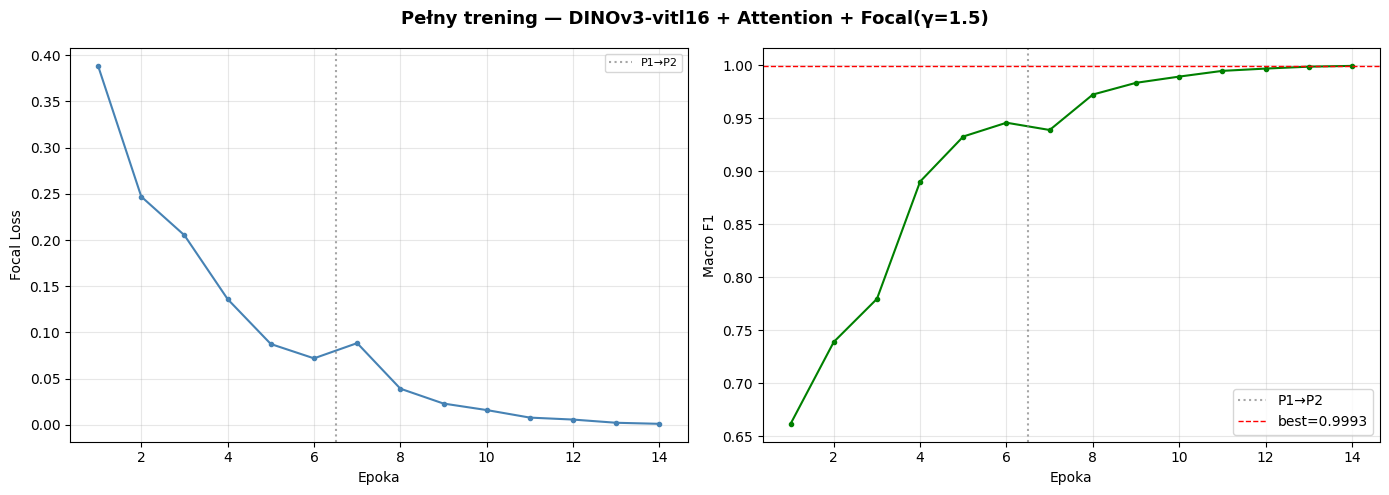

0.9993453270207903

In [33]:
plot_history(
    history,
    vlines=[(EPOCHS_P1 + 0.5, 'P1→P2')],
    title=f'Pełny trening — DINOv3-{DINOV3_VARIANT} + Attention + Focal(γ={FOCAL_GAMMA})',
    fname='full_training.png'
)

## Inferencja i plik submisji

In [34]:
ckpt = torch.load(SAVE_PHASE2, map_location=DEVICE)
bare(model).load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Wczytano finalny model  (Faza 2 F1={ckpt["best_f1"]:.4f})')

test_loader = DataLoader(
    PigTestDataset(test, VAL_TRANSFORM),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

all_row_ids, all_preds = [], []
with torch.no_grad():
    for bi, (imgs, row_ids) in enumerate(test_loader):
        with torch.amp.autocast('cuda', dtype=AMP_DTYPE, enabled=(DEVICE.type=='cuda')):
            out = model(imgs.to(DEVICE, non_blocking=True))
        preds = out.argmax(dim=1).cpu().tolist()
        all_row_ids.extend(list(row_ids))
        all_preds.extend(preds)
        bar = '█' * int(30*(bi+1)/len(test_loader)) + '░' * (30-int(30*(bi+1)/len(test_loader)))
        print(f'\r  |{bar}| {bi+1}/{len(test_loader)}', end='', flush=True)

print(f'\n{len(all_preds):,} predykcji')

submission = pd.DataFrame({'row_id': all_row_ids, 'class_id': all_preds})
sample_sub = pd.read_csv(BASE_DIR / 'sample_submission.csv')

assert set(submission['row_id']) == set(sample_sub['row_id']), 'Niezgodne row_id!'
assert submission['class_id'].between(0, 4).all(), 'Błędne class_id!'

submission = (
    submission.set_index('row_id')
              .reindex(sample_sub['row_id'])
              .reset_index()
)

print('\nRozkład predykcji:')
for cid, cnt in sorted(submission['class_id'].value_counts().items()):
    print(f'  [{cid}] {CLASS_NAMES[cid]:25s}: {cnt:,}  ({100*cnt/len(submission):.1f}%)')

submission.to_csv(SUBMISSION_PATH, index=False)
print(f'\nZapisano → {SUBMISSION_PATH}')
print(f'\nModel saved to:      {os.path.abspath(SAVE_PHASE2)}')
print(f'Submission saved to: {os.path.abspath(SUBMISSION_PATH)}')
print('Done ✓')

Wczytano finalny model  (Faza 2 F1=0.9993)
  |██████████████████████████████| 366/366
11,708 predykcji

Rozkład predykcji:
  [0] Lateral_lying_left       : 1,203  (10.3%)
  [1] Lateral_lying_right      : 1,303  (11.1%)
  [2] Sitting                  : 347  (3.0%)
  [3] Standing                 : 6,254  (53.4%)
  [4] Sternal_lying            : 2,601  (22.2%)

Zapisano → /kaggle/working/submission_dinov3_vitl16.csv

Model saved to:      /kaggle/working/dinov3_vitl16_phase2.pt
Submission saved to: /kaggle/working/submission_dinov3_vitl16.csv
Done ✓
